In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv("store_customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0


In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              1000 non-null   int64  
 1   Gender                  997 non-null    object 
 2   Age                     994 non-null    float64
 3   Annual Income (k$)      996 non-null    float64
 4   Spending Score (1-100)  994 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 39.2+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.000000,994.000000,996.000000,994.000000
mean,1499.500000,38.935614,57.149096,42.645875
std,288.819436,13.399880,28.628506,20.101589
min,1000.000000,18.000000,15.000000,1.000000
25%,1249.750000,30.000000,34.975000,31.000000
50%,1499.500000,36.000000,49.000000,47.000000
75%,1749.250000,44.000000,79.400000,57.000000
max,1999.000000,80.000000,144.100000,92.000000


In [17]:
df.isna().sum()

CustomerID                0
Gender                    3
Age                       6
Annual Income (k$)        4
Spending Score (1-100)    6
dtype: int64

In [18]:
df.drop("CustomerID", axis=1, inplace=True)

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Annual Income (k$)"] = df["Annual Income (k$)"].fillna(df["Annual Income (k$)"].median())
df["Spending Score (1-100)"] = df["Spending Score (1-100)"].fillna(df["Spending Score (1-100)"].median())
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

In [19]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,M,39.0,59.9,58.0
1,M,34.0,48.4,37.0
2,F,40.0,70.5,26.0
3,F,47.0,81.1,30.0
4,F,33.0,42.1,58.0


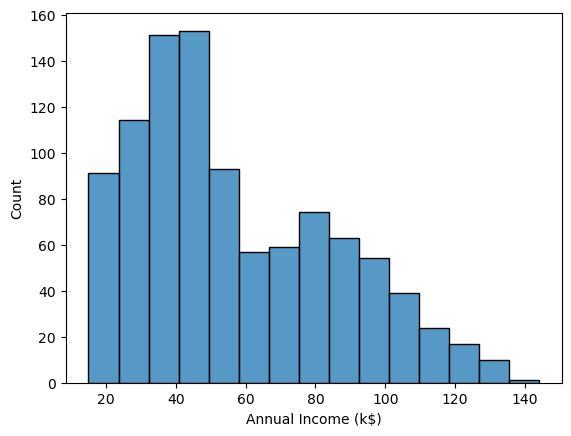

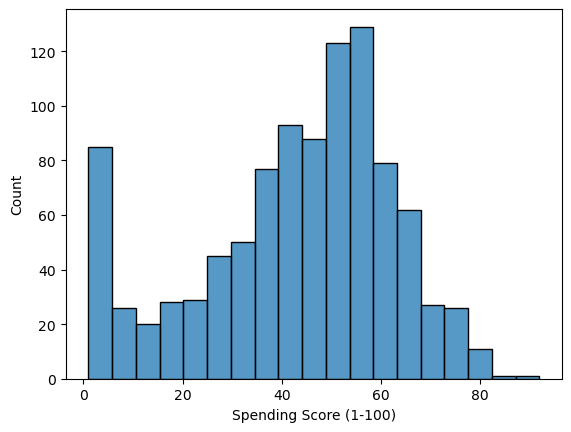

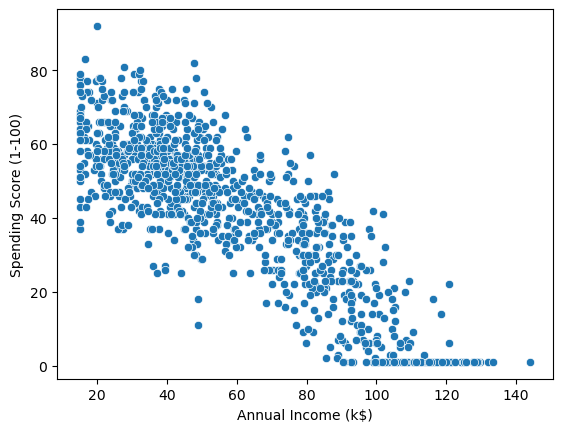

In [36]:
sns.histplot(df["Annual Income (k$)"])
plt.show()

sns.histplot(df["Spending Score (1-100)"])
plt.show()

sns.scatterplot(data=df,x="Annual Income (k$)",y="Spending Score (1-100)")
plt.show()

In [32]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

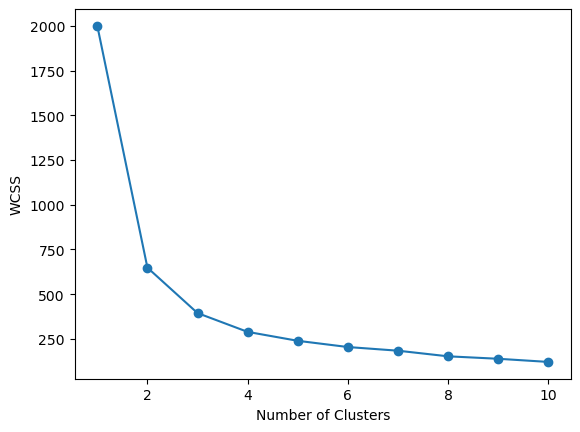

In [33]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [34]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

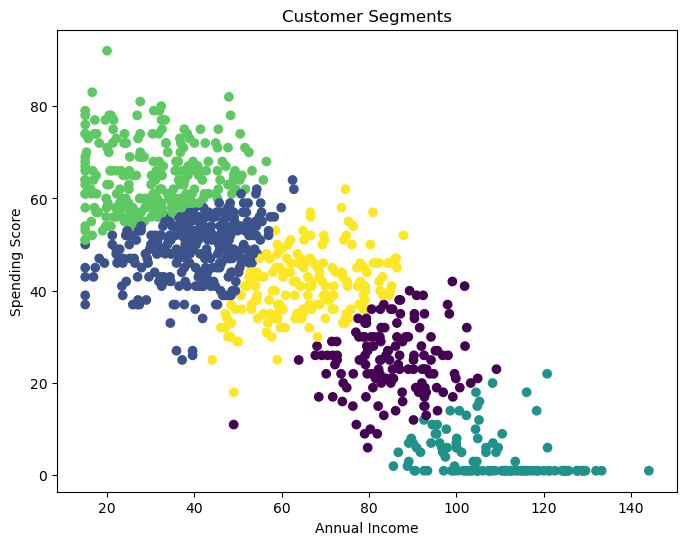

In [35]:
plt.figure(figsize=(8,6))
plt.scatter(X["Annual Income (k$)"],X["Spending Score (1-100)"],c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segments")
plt.show()

-----------------

Business Insights:

Cluster 1 → High Income, High Spending (Premium Customers)

Cluster 2 → High Income, Low Spending (Potential Customers)

Cluster 3 → Low Income, High Spending (Impulse Buyers)

Cluster 4 → Low Income, Low Spending (Low Engagement)

Cluster 5 → Average Customers